In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from rebar_object_detection import get_bounding_boxes
from ultralytics import YOLO

INFO:root:Detected 26 intersections.
INFO:root:intersections: [[     406.53      421.89      415.45      431.29]
 [     599.76       313.5      608.49      320.57]
 [     153.85      416.79       160.3       424.7]
 [     80.532      199.56      89.306      206.68]
 [     502.18      194.24      510.52      201.94]
 [     596.15      192.19       605.6       200.3]
 [     404.67      308.49       413.8      318.33]
 [     404.65      195.34      414.11       202.9]
 [     325.57      195.95      334.89      203.91]
 [     238.89      417.49      246.53      426.22]
 [     504.08      311.12      512.68      318.91]
 [     603.26      429.69      611.97      439.56]
 [     506.48      425.03      514.88      435.85]
 [     82.764      90.608      91.524       97.12]
 [     405.04      91.941      412.82      103.77]
 [     152.67      88.815      160.59      95.906]
 [     151.86      309.89      160.95      319.28]
 [      325.9      307.93      333.97      315.58]
 [     152.36      1

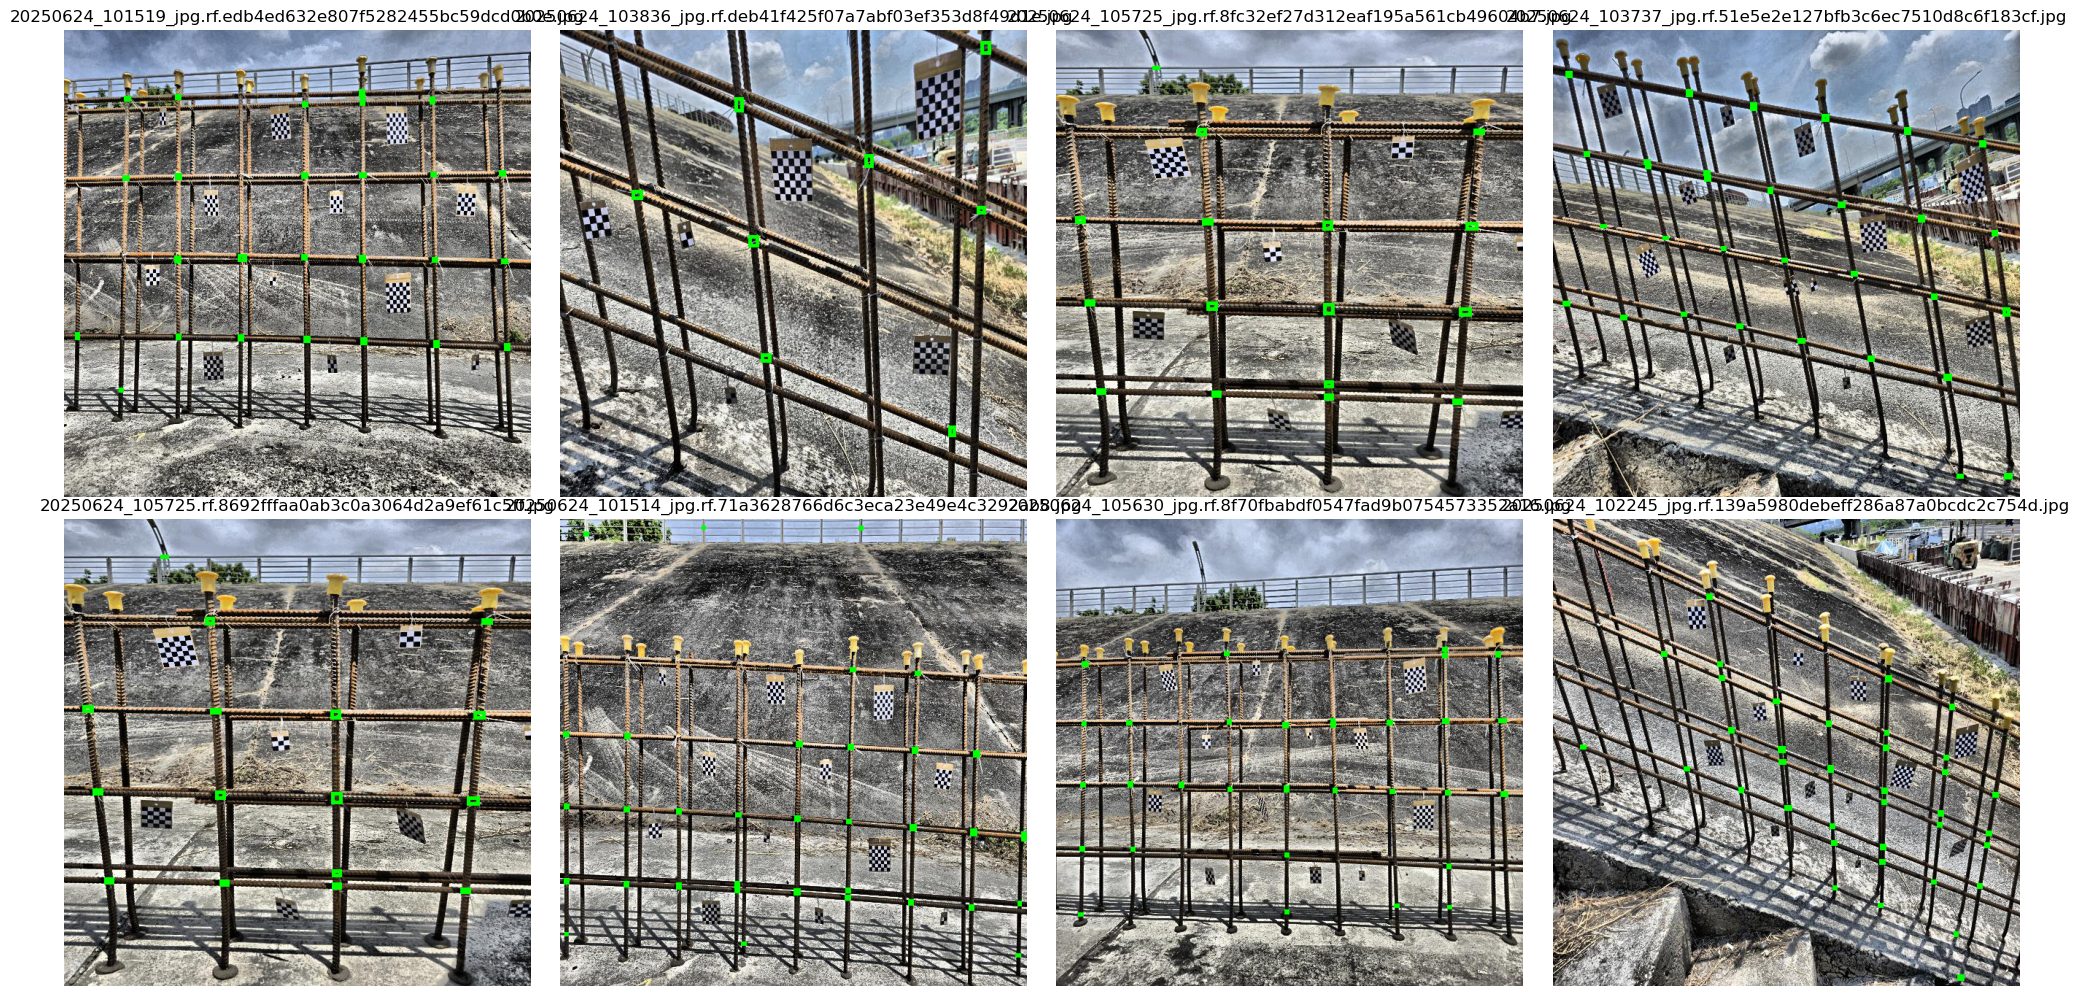

In [2]:
image_folder = "/Users/earnesthsiao/Downloads/intersect-detect-v2-2/test/images"  
# image_folder = "data/test/images"  
image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

num_images = len(image_files)
cols = 4  # 4 columns
rows = (num_images + cols - 1) // cols  # Calculate rows needed
fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))

if rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.ravel()

model_path = "runs/detect-yolo12/train/weights/best.pt"
# model_path = "runs/detect/tune/weights/best.pt"

for i, image_file in enumerate(image_files):
    image_path = os.path.join(image_folder, image_file)
    image = Image.open(image_path)
    draw = ImageDraw.Draw(image)

    bounding_boxes = get_bounding_boxes(image_path, model_path)
    for box in bounding_boxes:
        draw.rectangle(box, outline="lime", width=5)
    
    # Display
    axes[i].imshow(image)
    axes[i].set_title(f"{image_file}")
    axes[i].axis('off')

# Hide unused subplots
for i in range(num_images, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [3]:
model = YOLO('runs/detect-yolo12/train/weights/best.pt')
# model = YOLO("runs/detect/tune/weights/best.pt")
result = model.val(data='data/intersect-detect-v2/data.yaml', split='test')

Ultralytics 8.3.173 🚀 Python-3.12.7 torch-2.7.1 CPU (Apple M1)
YOLOv12l summary (fused): 283 layers, 26,339,843 parameters, 0 gradients, 88.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 561.0±312.2 MB/s, size: 308.8 KB)


val: Scanning /Users/VISLAB/rebar-works/yolo-intersect-detection/data/intersect-detect-v2/test/labels.cache... 8 images, 2 backgrounds, 0 corrupt: 100%|██████████| 10/10 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:07<00:00,  7.62s/it]


                   all         10        205      0.326      0.354      0.213     0.0479
Speed: 2.1ms preprocess, 747.2ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to runs/detect/val4
